In [1]:
import sys
import math
from pathlib import Path
!{sys.executable} -m pip install svgwrite ipywidgets

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "aitk" / "robots" / "world.py").exists():
    repo_root = repo_root.parent

sys.path.insert(0, str(repo_root))
sys.path.insert(0, str(repo_root / "aitk" / "algorithms"))

for name in list(sys.modules):
    if (
        name == "aitk"
        or name.startswith("aitk.")
        or name == "neat"
        or name.startswith("neat.")
    ):
        del sys.modules[name]

import aitk.robots
import aitk.utils
from aitk.robots.world import World
from aitk.utils import Grid
import ipywidgets as widgets
import neat
import random
from aitk.robots.utils import degrees_to_world
from neat.checkpoint import Checkpointer

widgets.IntSlider()
print("Using aitk from:", aitk.__file__)
print("Using neat from:", neat.__file__)

Defaulting to user installation because normal site-packages is not writeable

[notice] A new release of pip is available: 24.1.2 -> 26.0.1
[notice] To update, run: /Library/Developer/CommandLineTools/usr/bin/python3 -m pip install --upgrade pip
Using aitk from: /Users/reishirokawakami/Desktop/Projects/aitk_soccer_experiments/aitk/__init__.py
Using neat from: /Users/reishirokawakami/Desktop/Projects/aitk_soccer_experiments/aitk/algorithms/neat/__init__.py


In [2]:

def playSoccer(robot):
    """
    Controller function for player robots. 
    If it perceives a nearby ball, calculate the angle and the distance, and move the ball. 
    """

    if "stall_counter" not in robot.state:
        robot.state["stall_counter"] = 0

    if robot.stalled:
        robot.state["stall_counter"] += 1
    else:
        robot.state["stall_counter"] = 0

    if robot.state["stall_counter"] > 10:
        robot.speak("stuck")
        return True

    if robot.kick() == True: 
        ## record the time it takes to first reach the ball
        if robot.discovery_time == math.inf:
            robot.discovery_time = robot.world.time
            print("discovered ball at:", robot.discovery_time)

        robot.speak("kick")
        _, _, degrees = robot.get_pose() # direction it's facing 
        robot_velocity = robot.vx # robot.vy isn't used for .move(), so it stays 0
        # the last kick needs to be more than 0.2 seconds ago
        if (robot.prev_kicktime == None) or \
            (robot.prev_kicktime != None and robot.world.time - robot.prev_kicktime > 0.2):
            print("kicked", robot.num_kicks, "times")
            robot.num_kicks += 1
        robot.prev_kicktime = robot.world.time
        robot.stop()

        for ball in test_world._balls:
            ball.impact_from_robot(robot, degrees, robot_velocity)

    for ball in test_world._balls:
        robot.closest_distance = ball.closest_distance
        if ball.goal == True:
            robot.speak("goal!")
            robot.goal_time = robot.world.time
            print("goal at:", robot.goal_time)
            return True ## END SIMULATION
        else:
            robot.move(robot.state["translate"], robot.state["rotate"])


In [3]:

test_world = aitk.robots.World(width=200, height=200, scale=2.0)
test_world.add_wall("blue", 19,140,21,60)
robot = aitk.robots.Scribbler(x=170, y=170, a=90, max_trace_length=120)

test_world.add_robot(robot)
test_world.add_ball(100, 100)

robot.state["translate"], robot.state["rotate"] = 5, 0
max_time = 60
test_world.quiet = True
test_world.save()

test_world.watch()
test_world.run([playSoccer])

Random seed set to: 7846854
created backend
<class 'aitk.robots.backends.pil.PILBackend'>


Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x0…

0it [00:00, ?it/s]

True

## Evolving PlaySoccer()

The code above will help you understand and experiment with the basic setup. From the cells below, we will use NEAT to evolve find soccer player solution.

For the sake of simplicity, we will not make a new BallSensor or GoalSensor objects.

In [4]:

def reset_soccer_episode():
    """
    reset the ball position so the agents learns a generalizable policy
    """
    robot.world.reset()

    ball = robot.world._balls[0]
    ball.x = 100
    ball.y = 100
    ball.vx = 0
    ball.vy = 0
    ball.goal = False

    robot.x = 170
    robot.y = 170
    robot.a = degrees_to_world(90)
    robot.discovery_time = math.inf
    robot.goal_time = None
    robot.closest_distance = math.inf
    robot.num_kicks = 0
    robot.prev_kicktime = None

In [5]:
def eval_fitness(net, max_time, watch=False):
    """
    Function used to caclculate the fitness for an individual  
    A genome gets atmost max_time steps. 
    """

    stall_counter = 0
    robot.world.reset()
    reset_soccer_episode()
    robot.state["translate"] = 0
    robot.state["rotate"] = 0
    for i in range(max_time):
        x, y, direction = robot.get_pose()
        if robot.stalled:
            stall_counter += 1
        else:
            stall_counter = 0
        if stall_counter > 10:
            # end evaluation of stalled controllers
            break

        sensor_vals = robot.update_sensors() ## ball_distance, ball_angle, goal_distance, goal_angle
        output = net.activate(sensor_vals)
        robot.state["translate"] = output[0]
        robot.state["rotate"] = output[1]
        # Update command every step
        test_world.steps(1, [playSoccer], real_time=False, show=watch, quiet=True)

    ## calculate the fitness of the network by time to reach the ball and time to kick the ball into the goal
    fitness = 0

    # reward reaching/kicking the ball earlier
    if robot.discovery_time is not math.inf:
        # if this is large, it will incentivise going straight at the ball, which isn't optimal
        fitness += 3 * (1 - robot.discovery_time / max_time) # the better the longer time left until max_time
        print("fitness", 3 * (1 - robot.discovery_time / max_time), "for discovery_time" )
        
    # reward scoring earlier, more strongly
    if robot.goal_time != None:
        fitness += 10 * (1 - robot.goal_time / max_time)
        print("fitness", 10 *(1 - robot.goal_time / max_time), "for goal_time")
    
    # if it gets stuck, reduce the fitness
    if robot.stalled == True and robot.discovery_time == math.inf:
        fitness -= 0 # maybe making the robot not learn the basic movements, making it unable to re-kick the ball?

    # reward for kicking ball closer to the goal
    if robot.closest_distance is not math.inf and robot.num_kicks > 0:
        fitness += 3 * (2 - robot.closest_distance / robot.world.width)
        print("fitness", 3 * (2 - robot.closest_distance / robot.world.width), "for closest_distance")

    # reward for kicking ball multiple times -> proxy for staying close to the ball
    if robot.num_kicks != 0:
        fitness += 1 * (60 * robot.num_kicks / max_time) # one kick increases the fitness by 1
        print("fitness", 1 * (60 * robot.num_kicks / max_time), "for kicking", robot.num_kicks, "times")

    

    return fitness

In [6]:
def eval_population(pop, config):
    """
    Evaluates the fitness of an entire population  
    This function must take these two parameters
    """
    for genome_id, genome in pop:
        net = neat.nn.FeedForwardNetwork.create(genome, config)
        genome.fitness = eval_fitness(net, 60, watch=False)

In [7]:
def run(config_file):
    # Load configuration
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_file)

    # Create the population, which is the top-level object for a NEAT run.
    p = neat.Population(config)

    # Add a stdout reporter to show progress in the terminal.
    p.add_reporter(neat.StdOutReporter(True))
    stats = neat.StatisticsReporter()
    p.add_reporter(stats)
    # Uncomment this to save checkpoints every 5 generations
    p.add_reporter(neat.Checkpointer(25))

    winner = p.run(eval_population, 150) # runs for n generations

    # Display the winning genome.
    print('\nBest genome:\n{!s}'.format(winner))
    node_names = {-1:'ball_dist', -2:'ball_angle', -3:'goal_dist', -4:'goal_angle', 
                    -5:'gb_dist', -6:'gb_angle', 
                    0:'translate', 1: 'rotate'}

    neat.visualize.draw_net(config, winner, True, node_names=node_names)
    neat.visualize.plot_stats(stats, ylog=False, view=True)
    neat.visualize.plot_species(stats, view=True)
    
    return winner

In [8]:
%%writefile soccer.config
#--- parameters for the Robot Coverage experiment ---#

[NEAT]
fitness_criterion     = max
fitness_threshold     = 19
pop_size              = 50
reset_on_extinction   = False

[DefaultGenome]
# node activation options
activation_default      = relu 
activation_mutate_rate  = 0.0
activation_options      = relu

# node aggregation options
aggregation_default     = sum
aggregation_mutate_rate = 0.0
aggregation_options     = sum

# node bias options
bias_init_mean          = 0.0
bias_init_stdev         = 1.0
bias_max_value          = 30.0
bias_min_value          = -30.0
bias_mutate_power       = 0.5
bias_mutate_rate        = 0.7
bias_replace_rate       = 0.1

# genome compatibility options
compatibility_disjoint_coefficient = 1.0
compatibility_weight_coefficient   = 0.5

# connection add/remove rates
conn_add_prob           = 0.5
conn_delete_prob        = 0.5

# connection enable options
enabled_default         = True
enabled_mutate_rate     = 0.01

feed_forward            = True
initial_connection      = full_direct 

# node add/remove rates
node_add_prob           = 0.35
node_delete_prob        = 0.35

# network parameters
num_hidden              = 2
num_inputs              = 6
num_outputs             = 2

# node response options
response_init_mean      = 1.0
response_init_stdev     = 0.0
response_max_value      = 30.0
response_min_value      = -30.0
response_mutate_power   = 0.0
response_mutate_rate    = 0.0
response_replace_rate   = 0.0

# connection weight options
weight_init_mean        = 0.0
weight_init_stdev       = 1.0
weight_max_value        = 30
weight_min_value        = -30
weight_mutate_power     = 0.8 
weight_mutate_rate      = 0.8
weight_replace_rate     = 0.15 

[DefaultSpeciesSet]
compatibility_threshold = 2.0

[DefaultStagnation]
species_fitness_func = max
max_stagnation       = 20
species_elitism      = 1

[DefaultReproduction]
elitism            = 2
survival_threshold = 0.2

Overwriting soccer.config



 ****** Running generation 0 ****** 

Population's average fitness: 0.00000 stdev: 0.00000
Best fitness: 0.00000 - size: (4, 28) - species 1 - id 1
Average adjusted fitness: 0.000
Mean genetic distance 2.569, standard deviation 0.393
Population of 100 members in 50 species:
   ID   age  size  fitness  adj fit  stag
  ====  ===  ====  =======  =======  ====
     1    0     2      0.0    0.000     0
     2    0     2      0.0    0.000     0
     3    0     2      0.0    0.000     0
     4    0     2      0.0    0.000     0
     5    0     2      0.0    0.000     0
     6    0     2      0.0    0.000     0
     7    0     2      0.0    0.000     0
     8    0     2      0.0    0.000     0
     9    0     2      0.0    0.000     0
    10    0     2      0.0    0.000     0
    11    0     2      0.0    0.000     0
    12    0     2      0.0    0.000     0
    13    0     2      0.0    0.000     0
    14    0     2      0.0    0.000     0
    15    0     2      0.0    0.000     0
    16    

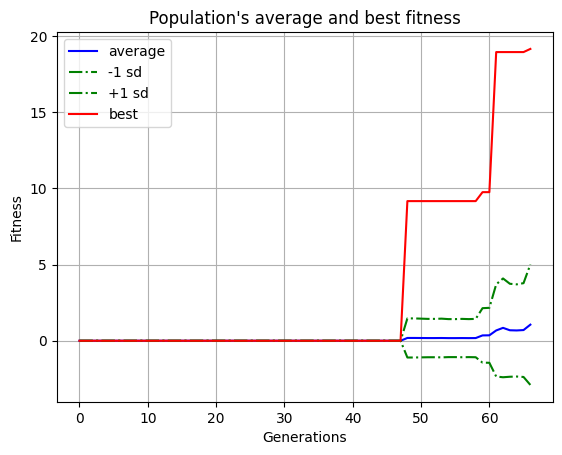

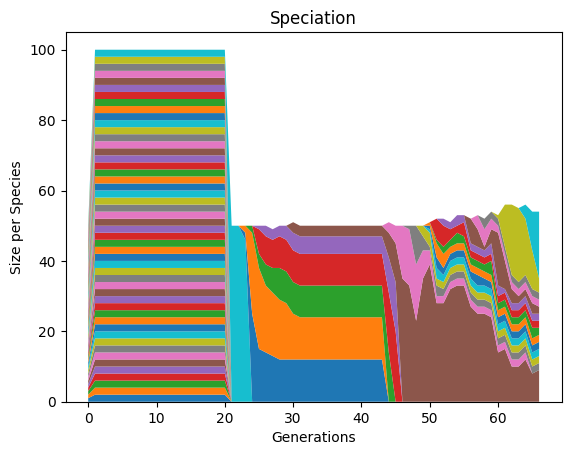

In [9]:
winner = run("soccer.config")

In [10]:
# Test the winning network
config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         "soccer.config")
winner_net = neat.nn.FeedForwardNetwork.create(winner, config)
eval_fitness(winner_net, 60, watch=True)

discovered ball at: 2.9
kicked 0 times
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
goal at: 3.9
fitness 2.855 for discovery_time
fitness 9.350000000000001 for goal_time
fitness 5.942860476597162 for closest_distance
fitness 1.0 for kicking 1 times


19.147860476597163

In [13]:
def winner_controller(net):
    sensor_vals = robot.update_sensors()
    output = winner_net.activate(sensor_vals)

    robot.state["translate"] = output[0]
    robot.state["rotate"] = output[1]

    return playSoccer(robot)
    
robot.world.reset()
reset_soccer_episode()
test_world.watch()
test_world.queit = True
test_world.run([winner_controller])

Image(value=b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00\x00\x01\x00\x01\x00\x00\xff\xdb\x00C\x00\x08\x06\x0…

0it [00:00, ?it/s]

discovered ball at: 2.9
kicked 0 times
goal at: 3.9


True

In [12]:
"""
Run this cell to replicate a past experiment
Make sure to change the filename to the specific checkpoint

Possible files: 
- neat-checkpoint-149_straight -> optimized result
- neat-checkpoint-149_bounce  -> solution with bouncing


"""

# def revive_soccer_episode():
#     """
#     reset the ball position so the agents learns a generalizable policy
#     """
#     robot.world.reset()

#     ball = robot.world._balls[0]
#     ball.x = 100
#     ball.y = 100
#     ball.vx = 0
#     ball.vy = 0
#     ball.goal = False

#     robot.x = 170
#     robot.y = 170
#     robot.a = 90
#     robot.discovery_time = math.inf
#     robot.goal_time = None
#     robot.closest_distance = math.inf
#     robot.num_kicks = 0
#     robot.prev_kicktime = None


# filename = "neat-checkpoint-149_bounce"
# p = Checkpointer.restore_checkpoint(filename)
# winner = p.best_genome
# # winner = p.run(eval_fitness)

# # Test the winning network
# config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
#                          neat.DefaultSpeciesSet, neat.DefaultStagnation,
#                          "revive.config")
# # winner = p.run(eval_fitness)
# winner_net = neat.nn.FeedForwardNetwork.create(winner, config)
# eval_fitness(winner_net, 60, watch=True)

# robot.world.reset()
# revive_soccer_episode()
# test_world.watch()
# test_world.queit = True
# test_world.run([winner_controller])

'\nRun this cell to replicate a past experiment\nMake sure to change the filename to the specific checkpoint\n\nPossible files: \n- neat-checkpoint-149_straight -> optimized result\n- neat-checkpoint-149_bounce  -> solution with bouncing\n\n\n'